==== PATH CHECK ====
Train images: 26684
Test images : 3000

==== TRAIN CSV INFO ====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30227 entries, 0 to 30226
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   patientId  30227 non-null  object 
 1   x          9555 non-null   float64
 2   y          9555 non-null   float64
 3   width      9555 non-null   float64
 4   height     9555 non-null   float64
 5   Target     30227 non-null  int64  
 6   class      30227 non-null  object 
 7   age        30227 non-null  int64  
 8   sex        30227 non-null  object 
 9   modality   30227 non-null  object 
 10  position   30227 non-null  object 
dtypes: float64(4), int64(2), object(5)
memory usage: 2.5+ MB
None

Train columns:
['patientId', 'x', 'y', 'width', 'height', 'Target', 'class', 'age', 'sex', 'modality', 'position']

Train head:
                              patientId      x      y  width  height  Target  \
0  0004cf

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:825: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:826: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


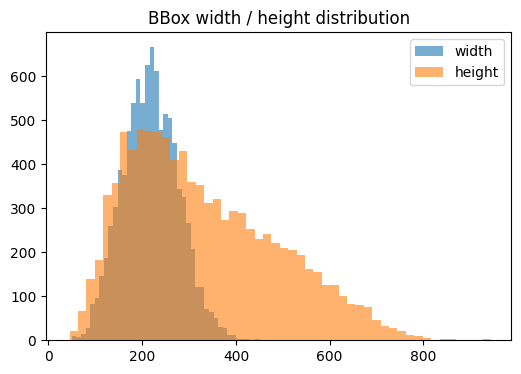


==== IMAGE INSPECTION ====

Image ID: 0004cfab-14fd-4e49-80ba-63a80b6bddd6
  Mode : L
  Size : (1024, 1024)
  Shape: (1024, 1024)
  Min/Max pixel: 0 245


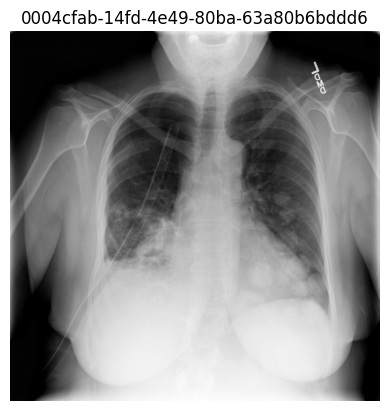


Image ID: 00313ee0-9eaa-42f4-b0ab-c148ed3241cd
  Mode : L
  Size : (1024, 1024)
  Shape: (1024, 1024)
  Min/Max pixel: 0 255


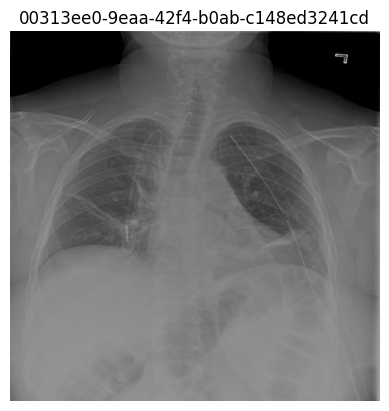


Image ID: 00322d4d-1c29-4943-afc9-b6754be640eb
  Mode : L
  Size : (1024, 1024)
  Shape: (1024, 1024)
  Min/Max pixel: 2 245


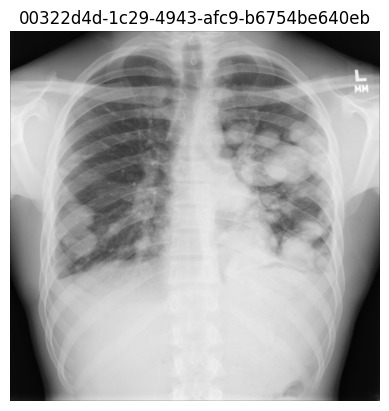


==== POS / NEG IMAGE COUNT ====
Positive images: 6012
Negative images: 20672

==== EDA DONE ====


In [1]:
# ===============================
# RSNA Pneumonia EDA
# ===============================

import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

DATA_ROOT = "/kaggle/input/rsna-pneumonia-processed-dataset"
TRAIN_IMG_DIR = f"{DATA_ROOT}/Training/Images"
TEST_IMG_DIR  = f"{DATA_ROOT}/Test"

TRAIN_CSV = f"{DATA_ROOT}/stage2_train_metadata.csv"
TEST_CSV  = f"{DATA_ROOT}/stage2_test_metadata.csv"

print("==== PATH CHECK ====")
print("Train images:", len(os.listdir(TRAIN_IMG_DIR)))
print("Test images :", len(os.listdir(TEST_IMG_DIR)))
print()

# ===============================
# 1. Load CSV
# ===============================
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("==== TRAIN CSV INFO ====")
print(train_df.info())
print()
print("Train columns:")
print(train_df.columns.tolist())
print()
print("Train head:")
print(train_df.head())
print("\n" + "="*50)

print("\n==== TEST CSV INFO ====")
print(test_df.info())
print()
print("Test columns:")
print(test_df.columns.tolist())
print()
print("Test head:")
print(test_df.head())
print("\n" + "="*50)

# ===============================
# 2. Check label distribution
# ===============================
print("\n==== LABEL DISTRIBUTION (TRAIN) ====")
if "Target" in train_df.columns:
    print(train_df["Target"].value_counts())
else:
    print("⚠️ No column named 'Target' found")

# ===============================
# 3. Group by image_id
# ===============================
img_col = "patientId" if "patientId" in train_df.columns else train_df.columns[0]

grouped = train_df.groupby(img_col)
num_images = grouped.ngroups
num_bbox = len(train_df)

print("\n==== BASIC STATS ====")
print("Number of unique images:", num_images)
print("Number of bbox rows    :", num_bbox)
print("Avg bbox per image     :", num_bbox / num_images)

# ===============================
# 4. Check bbox format
# ===============================
bbox_cols = [c for c in train_df.columns if c.lower() in ["x", "y", "width", "height", "x1", "y1", "x2", "y2"]]

print("\n==== POSSIBLE BBOX COLUMNS ====")
print(bbox_cols)

# Try common RSNA format
possible_bbox_sets = [
    ["x", "y", "width", "height"],
    ["x1", "y1", "x2", "y2"]
]

for s in possible_bbox_sets:
    if all(c in train_df.columns for c in s):
        print(f"Detected bbox format: {s}")

# ===============================
# 5. Analyze bbox size distribution
# ===============================
if all(c in train_df.columns for c in ["x", "y", "width", "height"]):
    print("\n==== BBOX SIZE STATS (width/height) ====")
    print(train_df[["width", "height"]].describe())

    plt.figure(figsize=(6,4))
    plt.hist(train_df["width"], bins=50, alpha=0.6, label="width")
    plt.hist(train_df["height"], bins=50, alpha=0.6, label="height")
    plt.legend()
    plt.title("BBox width / height distribution")
    plt.show()

# ===============================
# 6. Inspect sample images
# ===============================
print("\n==== IMAGE INSPECTION ====")

sample_ids = train_df[img_col].unique()[:3]

for pid in sample_ids:
    img_path = os.path.join(TRAIN_IMG_DIR, f"{pid}.png")
    if not os.path.exists(img_path):
        print(f"Image not found: {img_path}")
        continue

    img = Image.open(img_path)
    img_arr = np.array(img)

    print(f"\nImage ID: {pid}")
    print("  Mode :", img.mode)
    print("  Size :", img.size)
    print("  Shape:", img_arr.shape)
    print("  Min/Max pixel:", img_arr.min(), img_arr.max())

    plt.imshow(img_arr, cmap="gray" if img.mode != "RGB" else None)
    plt.title(f"{pid}")
    plt.axis("off")
    plt.show()

# ===============================
# 7. Negative samples check
# ===============================
if "Target" in train_df.columns:
    neg_images = train_df[train_df["Target"] == 0][img_col].nunique()
    pos_images = train_df[train_df["Target"] == 1][img_col].nunique()

    print("\n==== POS / NEG IMAGE COUNT ====")
    print("Positive images:", pos_images)
    print("Negative images:", neg_images)

print("\n==== EDA DONE ====")


In [2]:
# =====================
# IMPORT
# =====================
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# =====================
# CONFIG
# =====================
DATA_ROOT = "/kaggle/input/rsna-pneumonia-processed-dataset"
IMG_DIR = f"{DATA_ROOT}/Training/Images"
CSV_PATH = f"{DATA_ROOT}/stage2_train_metadata.csv"

NUM_EPOCHS = 16
BATCH_SIZE = 4
LR = 0.005
WEIGHT_DECAY = 1e-4

MIN_EPOCH_EARLY_STOP = 13
PATIENCE = 3

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cuda


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


In [4]:
class RSNADataset(Dataset):
    def __init__(self, df, img_dir):
        self.df = df
        self.img_dir = img_dir
        self.image_ids = df["patientId"].unique()

        self.transform = transforms.Compose([
            transforms.Resize((800, 800)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        pid = self.image_ids[idx]
        records = self.df[self.df["patientId"] == pid]

        img_path = os.path.join(self.img_dir, f"{pid}.png")
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)

        boxes = []
        labels = []

        if records.iloc[0]["Target"] == 1:
            for _, r in records.iterrows():
                x1, y1 = r["x"], r["y"]
                x2 = x1 + r["width"]
                y2 = y1 + r["height"]
                boxes.append([x1, y1, x2, y2])
                labels.append(1)

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx])
        }

        return img, target


In [5]:
def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)


In [6]:
df = pd.read_csv(CSV_PATH)

image_ids = df["patientId"].unique()
np.random.shuffle(image_ids)

split = int(0.8 * len(image_ids))
train_ids = image_ids[:split]
val_ids = image_ids[split:]

df_train = df[df["patientId"].isin(train_ids)]
df_val = df[df["patientId"].isin(val_ids)]

train_ds = RSNADataset(df_train, IMG_DIR)
val_ds = RSNADataset(df_val, IMG_DIR)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    collate_fn=collate_fn
)


In [7]:
model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features, num_classes=2
)

model.to(DEVICE)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:00<00:00, 207MB/s]  


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [8]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LR,
    momentum=0.9,
    weight_decay=WEIGHT_DECAY
)

scaler = torch.cuda.amp.GradScaler()


/tmp/ipykernel_47/1181539719.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [9]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from sklearn.metrics import roc_auc_score
# COCO-style mAP
map_metric = MeanAveragePrecision(
    iou_type="bbox",
    iou_thresholds=None,   # mặc định: 0.5:0.95
    rec_thresholds=None,
    max_detection_thresholds=[1, 10, 100]
)


In [10]:
def validate(model, loader, device):
    model.eval()
    map_metric.reset()

    all_scores = []
    all_labels = []

    with torch.no_grad():
        for images, targets in tqdm(loader, desc="Validation", leave=False):
            images = [img.to(device) for img in images]
            outputs = model(images)

            preds = []
            gts = []

            for out, tgt in zip(outputs, targets):
                preds.append({
                    "boxes": out["boxes"].cpu(),
                    "scores": out["scores"].cpu(),
                    "labels": out["labels"].cpu()
                })
                gts.append({
                    "boxes": tgt["boxes"],
                    "labels": tgt["labels"]
                })

                gt_label = 1 if len(tgt["boxes"]) > 0 else 0
                all_labels.append(gt_label)

                if len(out["scores"]) > 0:
                    all_scores.append(out["scores"].max().item())
                else:
                    all_scores.append(0.0)

            map_metric.update(preds, gts)

    result = map_metric.compute()

    metrics = {
        "mAP@0.5": result["map_50"].item(),
        "mAP@0.5:0.95": result["map"].item(),
        "Recall@0.5": result["mar_100"].item(),
        "Precision": result["map"].item()
    }

    try:
        metrics["AUC"] = roc_auc_score(all_labels, all_scores)
    except:
        metrics["AUC"] = 0.0

    return metrics


In [11]:
from torch.amp import autocast

def train_one_epoch(model, loader, optimizer, scaler, device, epoch):
    model.train()
    running_loss = 0.0

    pbar = tqdm(loader, desc=f"Train Epoch {epoch}", leave=False)
    for images, targets in pbar:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()

        with autocast(device_type="cuda"):
            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    return running_loss / len(loader)


In [12]:
import time
start_time = time.time()
patience_counter = 0

best_map50 = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n===== Epoch {epoch}/{NUM_EPOCHS} =====")

    train_loss = train_one_epoch(
        model, train_loader, optimizer, scaler, DEVICE, epoch
    )

    metrics = validate(model, val_loader, DEVICE)

    print(f"Train Loss      : {train_loss:.4f}")
    print(f"mAP@0.5         : {metrics['mAP@0.5']:.4f}")
    print(f"mAP@0.5:0.95    : {metrics['mAP@0.5:0.95']:.4f}")
    print(f"Recall@0.5      : {metrics['Recall@0.5']:.4f}")
    print(f"Precision       : {metrics['Precision']:.4f}")
    print(f"AUC (image-lvl) : {metrics['AUC']:.4f}")

    # Save last
    torch.save(model.state_dict(), "/kaggle/working/last_epoch.pth")

    # Save best by mAP@0.5
    improved = metrics["mAP@0.5"] > best_map50
    
    if improved:
        best_map50 = metrics["mAP@0.5"]
        torch.save(model.state_dict(), "/kaggle/working/best_map50.pth")
        patience_counter = 0
        print(" Best model saved (mAP@0.5 improved)")
    else:
        if epoch >= MIN_EPOCH_EARLY_STOP:
            patience_counter += 1

    
    elapsed_hours = (time.time() - start_time) / 3600
    
    if patience_counter >= PATIENCE:
        print(f" Early stopping triggered (no mAP@0.5 improvement for {PATIENCE} epochs)")
        break
    
    if elapsed_hours > 11.5:
        print(" Stopping due to Kaggle 12h limit")
        break




===== Epoch 1/16 =====


Train Loss      : 0.0681
mAP@0.5         : 0.2830
mAP@0.5:0.95    : 0.0768
Recall@0.5      : 0.2491
Precision       : 0.0768
AUC (image-lvl) : 0.8702
 Best model saved (mAP@0.5 improved)

===== Epoch 2/16 =====


Train Loss      : 0.0641
mAP@0.5         : 0.2925
mAP@0.5:0.95    : 0.0836
Recall@0.5      : 0.2441
Precision       : 0.0836
AUC (image-lvl) : 0.8674
 Best model saved (mAP@0.5 improved)

===== Epoch 3/16 =====


Train Loss      : 0.0626
mAP@0.5         : 0.3168
mAP@0.5:0.95    : 0.0885
Recall@0.5      : 0.2636
Precision       : 0.0885
AUC (image-lvl) : 0.8665
 Best model saved (mAP@0.5 improved)

===== Epoch 4/16 =====


Train Loss      : 0.0602
mAP@0.5         : 0.3138
mAP@0.5:0.95    : 0.0924
Recall@0.5      : 0.2834
Precision       : 0.0924
AUC (image-lvl) : 0.8739

===== Epoch 5/16 =====


...

Train Loss      : 0.0460
mAP@0.5         : 0.2856
mAP@0.5:0.95    : 0.0857
Recall@0.5      : 0.2367
Precision       : 0.0857
AUC (image-lvl) : 0.8618

===== Epoch 12/16 =====


Train Loss      : 0.0432
mAP@0.5         : 0.2465
mAP@0.5:0.95    : 0.0712
Recall@0.5      : 0.2366
Precision       : 0.0712
AUC (image-lvl) : 0.8482

===== Epoch 13/16 =====


Train Loss      : 0.0413
mAP@0.5         : 0.2355
mAP@0.5:0.95    : 0.0638
Recall@0.5      : 0.2417
Precision       : 0.0638
AUC (image-lvl) : 0.8497

===== Epoch 14/16 =====


Train Loss      : 0.0388
mAP@0.5         : 0.2418
mAP@0.5:0.95    : 0.0648
Recall@0.5      : 0.2382
Precision       : 0.0648
AUC (image-lvl) : 0.8602

===== Epoch 15/16 =====


Train Loss      : 0.0360
mAP@0.5         : 0.2373
mAP@0.5:0.95    : 0.0645
Recall@0.5      : 0.2343
Precision       : 0.0645
AUC (image-lvl) : 0.8605
 Early stopping triggered (no mAP@0.5 improvement for 3 epochs)
